# Cue-Centered Lag-CRP

> Compute and visualize lag-CRP where lags are defined relative to retrieval cues.

The cue-centered Lag-CRP measures how the probability of recalling an item depends on its serial lag from a *retrieval cue*, rather than from the previously recalled item. This is useful for experimental paradigms where participants receive cues at each recall event, and the analysis aims to assess whether cues reinstate temporal context.

$$\text{CRP}(\ell) = \frac{\text{actual transitions at cue-centered lag } \ell}{\text{available transitions at cue-centered lag } \ell}$$

The module requires a `cue_clips` field in the dataset that provides the cue item identifier for each recall event. A `_should_tabulate` mask controls which transitions are counted.

This notebook is parameterized for use with [papermill](https://papermill.readthedocs.io/).

| Parameter | Description |
|-----------|-------------|
| `run_tag` | Label for this analysis run |
| `data_path` | Path to HDF5 dataset file |
| `figure_dir` | Directory for saving figures |
| `figure_str` | Filename for saved figure (empty string to skip saving) |
| `ylim` | Y-axis limits as tuple, or `None` for auto |
| `trial_query` | Query string for trial selection |

: Notebook parameters {#tbl-parameters}

In [1]:
#| include: false
from nbdev.showdoc import show_doc

In [2]:
#| code-summary: Imports and setup
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxcmr.analyses.cue_centered_crp import (
    CueCenteredTabulation,
    cue_centered_crp,
    plot_cue_centered_crp,
    set_false_at_index,
    tabulate_trial,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [3]:
#| code-summary: Parameters for this analysis

run_tag = "cue_centered_crp"
data_path = "data/VRT_clips.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = None

In [4]:
#| code-summary: Load data and construct should_tabulate mask
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

# Construct should_tabulate: tabulate all valid recalls
should_tabulate = data["recalls"] > 0

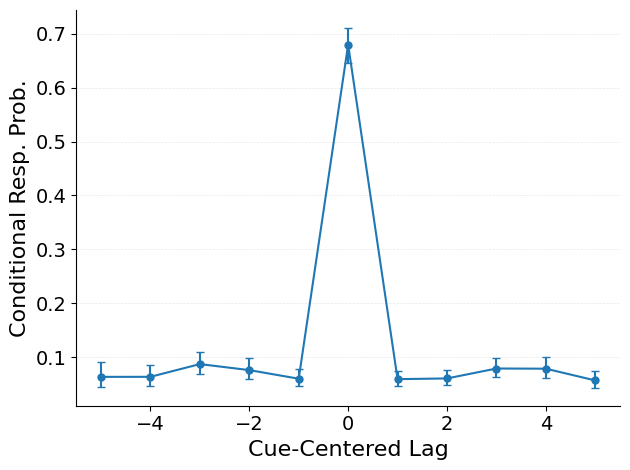

In [5]:
#| code-summary: Plot Cue-Centered Lag-CRP
#| label: fig-cue-centered-crp
#| fig-cap: "Cue-centered Lag-CRP showing response probability by cue-centered lag."
plot_cue_centered_crp(
    data,
    trial_mask,
    should_tabulate=should_tabulate,
    size=1,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

---

## Reference

In [6]:
#| echo: false
show_doc(plot_cue_centered_crp)

---

### plot_cue_centered_crp

>      plot_cue_centered_crp (datasets:Union[Sequence[jaxcmr.typing.RecallDatase
>                             t],jaxcmr.typing.RecallDataset], trial_masks:Union
>                             [Sequence[jaxtyping.Bool[Array,'trial_count']],jax
>                             typing.Bool[Array,'trial_count']], should_tabulate
>                             :Union[Sequence[jaxtyping.Bool[Array,'trial_countr
>                             ecall_events']],jaxtyping.Bool[Array,'trial_countr
>                             ecall_events']], max_lag:int=5,
>                             exclude_zero_lag:bool=False,
>                             color_cycle:Optional[list[str]]=None,
>                             labels:Optional[Sequence[str]]=None,
>                             contrast_name:Optional[str]=None,
>                             axis:Optional[matplotlib.axes._axes.Axes]=None,
>                             size:int=3, confidence_level:float=0.95)

*Plot cue-centered Lag-CRP curves.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| datasets | Union |  | Datasets containing trial data to plot. |
| trial_masks | Union |  | Masks selecting trials in datasets. |
| should_tabulate | Union |  | Boolean masks aligned to recall events. |
| max_lag | int | 5 | Maximum lag to plot. |
| exclude_zero_lag | bool | False | Whether to omit the zero-lag bin from plotting. |
| color_cycle | Optional | None | Colors for plotting each dataset. |
| labels | Optional | None | Legend labels for each dataset. |
| contrast_name | Optional | None | Legend title for contrasts. |
| axis | Optional | None | Existing matplotlib Axes to plot on. |
| size | int | 3 | Max study positions an item can occupy. |
| confidence_level | float | 0.95 | Confidence level for the bounds. |
| **Returns** | **Axes** |  | **Matplotlib Axes with cue-centered Lag-CRP plot.** |

In [7]:
# plot_cue_centered_crp returns an Axes object
from matplotlib.axes import Axes

ax = plot_cue_centered_crp(data, trial_mask, should_tabulate=should_tabulate, size=1)
assert isinstance(ax, Axes)
plt.close()

In [8]:
#| echo: false
show_doc(cue_centered_crp)

---

### cue_centered_crp

>      cue_centered_crp (dataset:jaxcmr.typing.RecallDataset, size:int=3)

*Compute cue-centered Lag-CRP.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| dataset | RecallDataset |  | Dataset with ``recalls``, ``pres_itemnos``,<br>``cue_clips``, and ``_should_tabulate``. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **Float[Array, 'lags']** |  | **CRP of length 2*L - 1; NaN where denominator is zero.** |

In [9]:
# cue_centered_crp returns a 1-D array of length 2*L - 1
recalls = jnp.array([[1, 2, 3, 0]], dtype=jnp.int32)
presentations = jnp.array([[1, 2, 3, 4]], dtype=jnp.int32)
cues = jnp.array([[1, 1, 2, 0]], dtype=jnp.int32)
should_tab = jnp.array([[True, True, True, False]], dtype=bool)

dataset = {
    "subject": jnp.ones((1, 1), dtype=jnp.int32),
    "listLength": jnp.full((1, 1), 4, dtype=jnp.int32),
    "pres_itemnos": presentations,
    "recalls": recalls,
    "cue_clips": cues,
    "_should_tabulate": should_tab,
}

result = cue_centered_crp(dataset, size=1)
assert result.shape == (7,)  # 2 * 4 - 1 = 7

In [10]:
#| echo: false
show_doc(tabulate_trial)

---

### tabulate_trial

>      tabulate_trial (recalls:jaxtyping.Integer[Array,'recall_events'],
>                      presentation:jaxtyping.Integer[Array,'study_events'],
>                      cues:jaxtyping.Integer[Array,'recall_events'],
>                      should_tabulate:jaxtyping.Bool[Array,'recall_events'],
>                      size:int=3)

*Tabulate cue-centered actual and available lags for a trial.*

|    | **Type** | **Default** | **Details** |
| -- | -------- | ----------- | ----------- |
| recalls | Integer[Array, 'recall_events'] |  | Recall sequence as item identifiers. |
| presentation | Integer[Array, 'study_events'] |  | Study presentation order for the trial. |
| cues | Integer[Array, 'recall_events'] |  | Cue item identifiers aligned to recall events. |
| should_tabulate | Bool[Array, 'recall_events'] |  | Boolean mask; True counts the transition. |
| size | int | 3 | Max study positions an item can occupy. |
| **Returns** | **tuple** |  | **Actual and available lag counts.** |

In [11]:
# tabulate_trial returns a pair of lag arrays
recalls_t = jnp.array([1, 2, 3], dtype=jnp.int32)
pres_t = jnp.array([1, 2, 3], dtype=jnp.int32)
cues_t = jnp.array([1, 1, 2], dtype=jnp.int32)
mask_t = jnp.array([True, True, True], dtype=bool)

actual, avail = tabulate_trial(recalls_t, pres_t, cues_t, mask_t, size=1)
assert actual.shape == (5,)  # 2 * 3 - 1 = 5
assert avail.shape == (5,)

In [12]:
#| echo: false
show_doc(set_false_at_index)

---

### set_false_at_index

>      set_false_at_index (vec:jaxtyping.Bool[Array,'positions'],
>                          i:jaxtyping.Integer[Array,'']|int)

*Set ``vec[i - 1]`` to ``False`` using 1-based indexing.*

|    | **Type** | **Details** |
| -- | -------- | ----------- |
| vec | Bool[Array, 'positions'] | Boolean availability vector. |
| i | jaxtyping.Integer[Array, ''] \| int | 1-based index to clear; ``0`` is a no-op sentinel. |
| **Returns** | **tuple** | **Updated vector and ``None``.** |

In [13]:
# 1-based indexing: index 3 clears position 2 (0-based)
vec = jnp.array([True, True, True, True], dtype=bool)
updated, _ = set_false_at_index(vec, 3)
assert updated.tolist() == [True, True, False, True]

# Index 0 is a no-op sentinel
unchanged, _ = set_false_at_index(vec, 0)
assert unchanged.tolist() == [True, True, True, True]